In [1]:
import mdtraj as md
import numpy as np

from tqdm import tqdm
from glob import glob

from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
def sci_notation_no_sigfigs(number, pos):
    a, b = f"{number:.0e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"


def sci_notation_one_sigfig(number, pos):
    a, b = f"{number:.1e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"

## Load MD and Crystal data

In [3]:
ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 1)'

def load_pdbs(glob_pattern):
    
    crystals = None
    crystal_chis = []

    first = True
    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:
            
            trj = md.load_pdb(pdb)
            idx = trj.top.select(ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            chi_atoms, chi = md.compute_chi1(trj)
            crystal_chis.extend(chi)

            if first:
                chi_idx = [ trj.topology.atom(int(a)).residue.index for a in chi_atoms[:,0] ]
                first = False

            idx = trj.top.select('name == CA')
            trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj

        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)

    crystals = crystals.center_coordinates()
    crystal_chis = np.array(crystal_chis)
    
    return crystals, crystal_chis

In [4]:
crystals, crystal_chis = load_pdbs('/Users/tjlane/Desktop/open_well_series_data/*.pdb')

100%|██████████| 7/7 [00:00<00:00, 13.87it/s]


In [5]:
print(crystals.xyz.shape, crystal_chis.shape)

(7, 301, 3) (7, 259)


In [6]:
active_site_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 3

residues = list(crystals.top.residues)
asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in active_site_residues ]

print(asr_names)

['HIS41', 'MET49', 'GLY143', 'SER144', 'CYS145', 'HIS163', 'HIS164', 'MET165', 'GLU166', 'LEU167', 'ASP187', 'ARG188', 'GLN189', 'THR190', 'ALA191', 'GLN192']


## Compute Ca covariance tensor

In [7]:
def isotropic_cov(xyz):
    
    # we want X.T * X summed over last dim
    # put it in B-factor units
    S = 8.0 * np.square(np.pi) * ( np.cov(xyz[:,:,0].T) + np.cov(xyz[:,:,1].T) + np.cov(xyz[:,:,2].T) )
    
    return S


def abs_cov(xyz):
    
    n_data  = xyz.shape[0]
    n_atoms = xyz.shape[1]

    xyz_centered = xyz - np.mean(xyz, axis=0)[None,:,:]
    assert xyz_centered.shape == xyz.shape, xyz_centered.shape
    S = np.einsum('aik,ajl->ijkl', xyz_centered, xyz_centered)
    S = S / float(xyz.shape[0] - 1)
    
    S = np.sum(np.abs(S), axis=(2,3))
    
    return S


def bootstrap_iso_cov(xyz, n_samples=10, debug=False):
    
    if debug:
        sigmas = np.zeros([n_samples, xyz.shape[1], xyz.shape[1]])
    
    # running variance estimate
    # https://www.johndcook.com/blog/standard_deviation/
    
    for k in range(n_samples):
        
        smpl_idx = np.random.randint(0, xyz.shape[0], size=xyz.shape[0])
        smpl = xyz[smpl_idx,:,:]
        
        x = isotropic_cov(smpl)
        
        if debug:
            sigmas[k] = x
        
        if k == 0:
            M_km1 = x
            S_km1 = np.zeros_like(x)
        else:
            M_k = M_km1 + (x-M_km1) / (k+1)
            S_k = S_km1 + (x-M_km1) * (x-M_k)
            M_km1 = M_k
            S_km1 = S_k
        
    if debug:
        resi = 55
        print(np.sqrt(S_k / k)[resi,resi])
        print(np.std(sigmas[:,resi,resi]))
    
    return np.sqrt(S_k / k)

In [8]:
S_xtal = isotropic_cov(crystals.xyz)

In [9]:
err_S_xtal = bootstrap_iso_cov(crystals.xyz, n_samples=1000)

0.7058185112838079


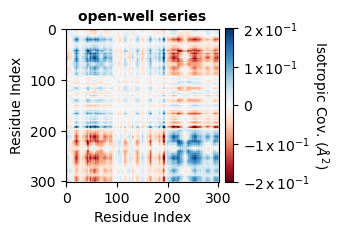

In [14]:
ticks = np.arange(0, crystals.xyz.shape[1], 100)
cmap = 'RdBu'

# title, matrix to plot, filename to save
dataset = (r'open-well series', S_xtal, "open_well_series")
 


# how much to zoom colorbar
scale = 0.2


figsize = (3.5,3.5)

fig = plt.figure(figsize=figsize)
ax1 = plt.subplot(111)

ax1.set_title(dataset[0], 
                fontweight='bold', fontsize=10)


print(dataset[1].max())
im = ax1.imshow(
    dataset[1],
    cmap=cmap, 
    vmin=-scale,
    vmax=scale,
)

ax1.set_xticks(ticks)
ax1.set_xticklabels([str(int(t)) for t in ticks])
ax1.set_yticks(ticks)
ax1.set_yticklabels([str(int(t)) for t in ticks])
ax1.set_xlabel('Residue Index')
ax1.set_ylabel('Residue Index')

# ax1.set_xticks([])
# ax1.set_yticks([])

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, format=FuncFormatter(sci_notation_no_sigfigs))

cbar.set_label('Isotropic Cov. ($\AA^2$)', rotation=270, labelpad=15)

plt.tight_layout()
#plt.savefig(f'./figures/covariance_matrices/{dataset[2]}.pdf')
plt.show()

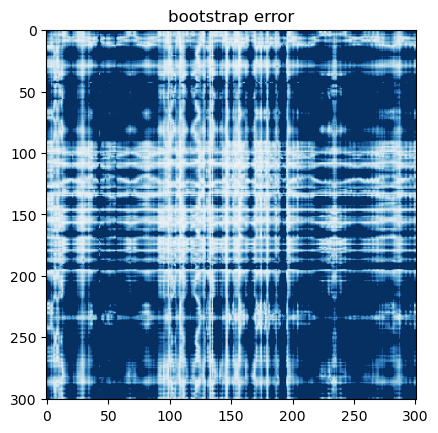

In [16]:
plt.figure()
plt.title('bootstrap error')
plt.imshow(err_S_xtal, cmap=cmap, vmin=-scale/10, vmax=scale/10)
plt.show()